<a href="https://colab.research.google.com/github/esh-g/mnist-MLP/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

The first element of each digit in the mnist is just the number, so we need to remove that for the digit pixels and retain it for the training steps.

array([7, 2, 1, ..., 2, 4, 0])

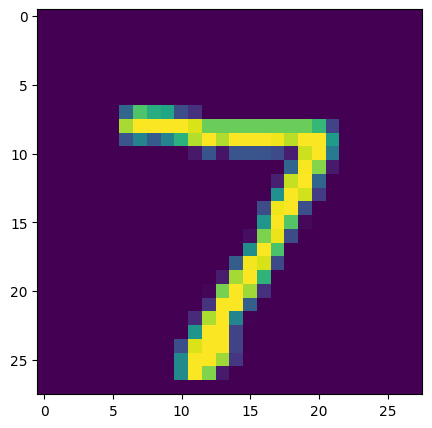

In [4]:
mnist = np.loadtxt('./sample_data/mnist_test.csv', delimiter=',')

number_of_samples = 5000

train_data = mnist[:number_of_samples]
correct_values = train_data[:, 0].astype(int)
mnist = train_data[:, 1:].astype(np.float32) / 255.0

fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(mnist[0].reshape(28, 28));
correct_values


I referred to the book "Introduction to Deep Learning" by Eugene Charniak in the BITS Library, as he mentions using the 784 -> 128 -> 10 architecture for the mnist database and the cross entropy loss.

I also watched the Welsh labs, [NN demistified series](https://youtu.be/bxe2T-V8XRs?si=ENgjXaG3VBvVy9I6)

In addition, videos by sentdex based on nnfs (neural networks from scratch were also useful in explainatins of activation functions and implementation without any libraries.)

I also got familiar with the standard notations like:

$$\begin{aligned} \text{Textbook Convention (Single Column Vector):} \quad & z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]} \\ \text{NumPy / Batch Convention (Row Vectors):} \quad & Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]} \end{aligned}$$

Where Z is the output of each layer l and A is the output from the last layer. weights and biases or layer l are W and b

# Forward Pass

In [13]:
# Neural Network layers 784 -> 128 -> 10, this was the standard structure recommended in many sources

np.random.seed(0)
weights1 = np.random.randn(784, 128) * np.sqrt(2.0 / 784) # Normalisation needed because otherwise softmax just gives one for a number and 0s for other nine, instead of smooth probs
biases1 = np.zeros((1, 128))

weights2 = np.random.randn(128, 10) * np.sqrt(1.0 / 128)
biases2 = np.zeros((1, 10))

def softmax(layer):
  shifted_z = layer - np.max(layer, axis=-1, keepdims=True) # shifted to prevent weird edge cases where e^(large number) blows up too much
  exp_z = np.exp(shifted_z)
  return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

z1 = np.ndarray((number_of_samples, 128))
a1 = np.ndarray((number_of_samples, 128))
a2 = np.ndarray((number_of_samples, 10))

def forward_pass():
  global a1, a2, z1
  # layer 1
  z1 = (mnist @ weights1) + biases1
  a1 = np.maximum(0, z1) # reLU is with np.maximum

  #layer 2
  a2 = softmax((a1 @ weights2) + biases2)

  return a2

Y_pred = forward_pass()

"""
If I have the last layer predictions as a 1x10 vector as Y. now I need dL/db(2) where b(2) is the (1x10) vector of biases for the last layer. Is that just equal to the derivative of the softmax function?
"""

#   for i in range(number_of_samples):
#     loss[i] = -np.log()

# def calculate_gradients():
#   # I'll try getting the gradients for each Weight matrix and bias vector





'\nIf I have the last layer predictions as a 1x10 vector as Y. now I need dL/db(2) where b(2) is the (1x10) vector of biases for the last layer. Is that just equal to the derivative of the softmax function?\n'


I am thinking of having separate matricies for the weights, biases and stuff
The equation looks like L = -log(y(k)) where y(k) is the softmax of the correct one hot value.



# Loss Calculation

Using the recommended cross-entropy loss

$$L = -\sum_{k=1}^n y_k \log(\hat{y}_k)$$

$y_k$ is the correct value and $\hat{y}_k$ is pred. For one hot vectors, since only one class is 1, and since the rest $y_k$ where $k$ is not equal to target, is zero, loss becomes:
  $$L = -\log(\hat{y}_c)$$

In [6]:
# categorical_cross_entropy_loss = np.zeros((number_of_samples, 1))


def compute_cross_entropy_loss():

  # We need to index only the correct class in the one hot vector, others will be automatically zero as
  # numpy allows indicing with arrays to Y_pred[[0, 1, 2], [2, 3, 4]] -> Y_pred[0, 2], Y_pred[1, 3] ...
  return -np.log(Y_pred[range(number_of_samples), correct_values] + 10e-15)
  # 10e-15 to deal with inf behaviour with zero thing


L = compute_cross_entropy_loss()

# Backpropagation

This is where the real math starts. I was able to derive the expressions for computing gradients for this sort of network and decided to store the gradients in matrices that resemble the dimensions of their respective parameters (weights and biases).

**Calculating Gradients**

In [7]:
# z = W.A + B
# dL/dz = y_pred if i != k, dL/dz = y_pred - 1 when i == k
# dL/dz = dL/db

# since differentiation is linear, differentiating each dL/db2 element will be the same as
# differntiating the sum, so we can just accumulate dL_db2 for each batch of samples.
# the math for other gradients is explained in my handwritten notes photographs
# the slight discrepancy in the notes is that here i used input layer as X, hidden layer as a1 and output as a2
# whereas in the notes, a2 was the hidden layer and a1 was the input layer

def calculate_gradients(): # this was implemented by hand and as it have a for loop, it is too slow.
  global dL_db1, dL_db2, dL_dw1, dL_dw2, da_dz

  da_dz = (z1 > 0).astype(float)
  dL_dw1 = np.zeros((784, 128))
  dL_db1 = np.zeros((1, 128))
  dL_dw2 = np.zeros((128, 10))
  dL_db2 = np.zeros((1, 10))
  error = np.zeros((1, 10))

  for i in range(number_of_samples):
      error[0] = Y_pred[i]
      error[0, correct_values[i]] -= 1  # delta2: shape (1, 10)

      dL_db2 += error
      dL_dw2 += a1[i].reshape(128, 1) @ error


      delta1 = (error @ weights2.T) * da_dz[i]  # shape (1, 128)

      dL_db1 += delta1
      dL_dw1 += mnist[i].reshape(784, 1) @ delta1

  # Average gradients over the batch
  dL_dw1 /= number_of_samples
  dL_db1 /= number_of_samples
  dL_dw2 /= number_of_samples
  dL_db2 /= number_of_samples


def calculate_gradients_vectorised(): # optimised numpy implementation without for loop
    global dL_db1, dL_db2, dL_dw1, dL_dw2

    # 1. Output layer error (delta2): shape (5000, 10)
    delta2 = Y_pred.copy()
    delta2[np.arange(number_of_samples), correct_values] -= 1

    # 2. Output layer gradients
    # (128, 5000) @ (5000, 10) -> (128, 10)
    dL_dw2 = (a1.T @ delta2) / number_of_samples
    dL_db2 = np.sum(delta2, axis=0, keepdims=True) / number_of_samples

    # 3. Hidden layer error (delta1): shape (5000, 128)
    # (5000, 10) @ (10, 128) * (5000, 128) -> (5000, 128)
    delta1 = (delta2 @ weights2.T) * (z1 > 0).astype(float)

    # 4. Hidden layer gradients
    # (784, 5000) @ (5000, 128) -> (784, 128)
    dL_dw1 = (mnist.T @ delta1) / number_of_samples
    dL_db1 = np.sum(delta1, axis=0, keepdims=True) / number_of_samples




**Gradient Descent**

In [8]:
steps = 1000

def update_gradients(alpha=1):
  global weights1, weights2, biases1, biases2

  weights1 += -alpha*dL_dw1
  weights2 += -alpha*dL_dw2
  biases1 += -alpha*dL_db1
  biases2 += -alpha*dL_db2

for i in range(steps):
    Y_pred = forward_pass()
    loss = compute_cross_entropy_loss()

    if i % 10 == 0:
        print(f"Step {i} Mean Loss: {np.mean(loss)}")

    calculate_gradients_vectorised()

    update_gradients(alpha=0.1)




Step 0 Mean Loss: 2.3567910324342467
Step 10 Mean Loss: 1.870777324129051
Step 20 Mean Loss: 1.4487803003640116
Step 30 Mean Loss: 1.13283086393847
Step 40 Mean Loss: 0.9296625717067871
Step 50 Mean Loss: 0.7997836219163706
Step 60 Mean Loss: 0.7121586895763196
Step 70 Mean Loss: 0.6493442988051341
Step 80 Mean Loss: 0.6020787838325905
Step 90 Mean Loss: 0.5650307904757795
Step 100 Mean Loss: 0.5350636364330862
Step 110 Mean Loss: 0.5102202949869413
Step 120 Mean Loss: 0.48919916629610277
Step 130 Mean Loss: 0.4710967243159804
Step 140 Mean Loss: 0.4553033148944403
Step 150 Mean Loss: 0.44133889394848513
Step 160 Mean Loss: 0.42884368028267444
Step 170 Mean Loss: 0.4175722119251357
Step 180 Mean Loss: 0.407333063229494
Step 190 Mean Loss: 0.39795973923722294
Step 200 Mean Loss: 0.38931474052484205
Step 210 Mean Loss: 0.3812955274230741
Step 220 Mean Loss: 0.373836532533699
Step 230 Mean Loss: 0.36686516032596755
Step 240 Mean Loss: 0.36032352109272214
Step 250 Mean Loss: 0.354149284833

# Testing the model on rest of the data

In [17]:
full_dataset = np.loadtxt('./sample_data/mnist_test.csv', delimiter=',')
test_data = full_dataset[5000:]
# Getting the remaining 5000 digits to test on
test_labels = test_data[:, 0].astype(int)
test_pixels = test_data[:, 1:].astype(np.float32) / 255.0

# A small forward pass
z1_test = (test_pixels @ weights1) + biases1
a1_test = np.maximum(0, z1_test)
test_probs = softmax((a1_test @ weights2) + biases2)


test_preds = np.argmax(test_probs, axis=1) # gets the highest propbability class
test_acc = np.mean(test_preds == test_labels) * 100
test_loss = -np.mean(np.log(test_probs[np.arange(len(test_labels)), test_labels] + 1e-15))


train_preds = np.argmax(Y_pred, axis=1)
train_acc = np.mean(train_preds == correct_values) * 100

print(f"Training Accuracy : {train_acc}% | Final Train Loss: {np.mean(loss)}")
print(f"Test Accuracy: {test_acc}% | Test Loss: {test_loss}")

Training Accuracy : 100.0% | Final Train Loss: 0.005042543699318371
Test Accuracy: 93.14% | Test Loss: 0.3255784646573443


# Comparing gradients with pytorch

In [10]:
import torch
import torch.nn.functional as F

# 1. Ensure fresh NumPy forward & backward passes
Y_pred = forward_pass()
calculate_gradients_vectorised()

# 2. Convert inputs and parameters to PyTorch tensors (using float64 for exact precision)
X_torch = torch.from_numpy(mnist.astype(np.float64))
y_torch = torch.from_numpy(correct_values.astype(np.int64))

W1_torch = torch.tensor(weights1, dtype=torch.float64, requires_grad=True)
b1_torch = torch.tensor(biases1, dtype=torch.float64, requires_grad=True)
W2_torch = torch.tensor(weights2, dtype=torch.float64, requires_grad=True)
b2_torch = torch.tensor(biases2, dtype=torch.float64, requires_grad=True)

# 3. PyTorch forward pass
z1_torch = (X_torch @ W1_torch) + b1_torch
a1_torch = F.relu(z1_torch)
z2_torch = (a1_torch @ W2_torch) + b2_torch

# Cross-entropy with mean reduction means it will also divide by number_of_samples
loss_torch = F.cross_entropy(z2_torch, y_torch, reduction='mean')

# 4. PyTorch backward pass
loss_torch.backward()

# 5. Extract PyTorch gradients
grad_w1_torch = W1_torch.grad.numpy()
grad_b1_torch = b1_torch.grad.numpy()
grad_w2_torch = W2_torch.grad.numpy()
grad_b2_torch = b2_torch.grad.numpy()

# 6. Compare with your custom gradients
comparisons = [
    ("W1", dL_dw1, grad_w1_torch),
    ("b1", dL_db1, grad_b1_torch),
    ("W2", dL_dw2, grad_w2_torch),
    ("b2", dL_db2, grad_b2_torch),
]

print(f"{'Param':<6} | {'Max Absolute Error':<20} | {'Match (allclose)?'}")
print("-" * 50)
for name, custom_grad, torch_grad in comparisons:
    max_err = np.max(np.abs(custom_grad - torch_grad))
    matches = np.allclose(custom_grad, torch_grad, atol=1e-7)
    print(f"{name:<6} | {max_err:<20.2e} | {matches}")

Param  | Max Absolute Error   | Match (allclose)?
--------------------------------------------------
W1     | 2.71e-18             | True
b1     | 4.73e-18             | True
W2     | 1.22e-17             | True
b2     | 3.42e-18             | True


# Stretch Goal
I tried adding the momentum to the optimiser and the improvement in the loss was shocking. The accuracy improved from ~91% to ~93% with just a better optimiser.

In [14]:
# <STRETCH GOAL>, adding momentum to the gradient descent as a better optimiser
v_w1 = np.zeros_like(weights1)
v_b1 = np.zeros_like(biases1)
v_w2 = np.zeros_like(weights2)
v_b2 = np.zeros_like(biases2)

def update_gradients_momentum(alpha=0.01, beta=0.9):
    global weights1, weights2, biases1, biases2
    global v_w1, v_b1, v_w2, v_b2

    # Update velocity
    v_w1 = beta * v_w1 + alpha * dL_dw1
    v_b1 = beta * v_b1 + alpha * dL_db1
    v_w2 = beta * v_w2 + alpha * dL_dw2
    v_b2 = beta * v_b2 + alpha * dL_db2

    # Update parameters
    weights1 -= v_w1
    biases1  -= v_b1
    weights2 -= v_w2
    biases2  -= v_b2

for i in range(steps):
  Y_pred = forward_pass()
  loss = compute_cross_entropy_loss()

  if i % 10 == 0:
      print(f"Step {i} Mean Loss: {np.mean(loss)}")

  calculate_gradients_vectorised()

  update_gradients_momentum(alpha=0.1)

Step 0 Mean Loss: 2.3567910324342467
Step 10 Mean Loss: 0.9726937615853538
Step 20 Mean Loss: 0.5163401262658606
Step 30 Mean Loss: 0.4071811109110407
Step 40 Mean Loss: 0.3360148134963809
Step 50 Mean Loss: 0.2925375235215305
Step 60 Mean Loss: 0.2642672718373629
Step 70 Mean Loss: 0.24273634442711736
Step 80 Mean Loss: 0.22416243945223133
Step 90 Mean Loss: 0.20768334123390508
Step 100 Mean Loss: 0.1928113371310597
Step 110 Mean Loss: 0.17926272213689345
Step 120 Mean Loss: 0.1667780157229699
Step 130 Mean Loss: 0.1551885042602909
Step 140 Mean Loss: 0.14447394369834254
Step 150 Mean Loss: 0.13459481172851065
Step 160 Mean Loss: 0.12543131219865025
Step 170 Mean Loss: 0.11688440091765091
Step 180 Mean Loss: 0.1089531163391532
Step 190 Mean Loss: 0.10159116335996851
Step 200 Mean Loss: 0.09471893372779441
Step 210 Mean Loss: 0.08833380383388384
Step 220 Mean Loss: 0.08239388735744434
Step 230 Mean Loss: 0.07687221364359285
Step 240 Mean Loss: 0.07175877753023557
Step 250 Mean Loss: 0.

# An Interesting backward pass experiment

I thought what would happen if we give the model a one-hot encoded 8 in it's last layer and check what would be the output in the first layer. Will the image resemble an 8??

*Disclaimer: The following code is almost entirely written by an LLM. But the idea was original*

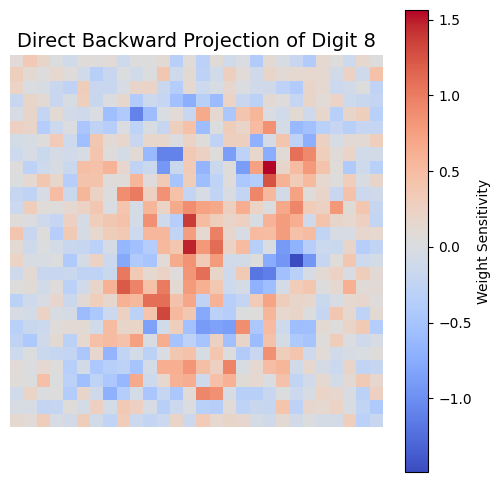

In [18]:
import matplotlib.pyplot as plt

# 1. Create a one-hot vector for digit 8
one_hot_8 = np.zeros((1, 10))
one_hot_8[0, 8] = 1.0

# 2. Back-project through the layers
# (1, 10) @ (10, 128) -> (1, 128)
hidden_pattern = one_hot_8 @ weights2.T

# (1, 128) @ (128, 784) -> (1, 784)
input_reconstruction = hidden_pattern @ weights1.T

# 3. Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(input_reconstruction.reshape(28, 28), cmap='coolwarm')
plt.colorbar(label="Weight Sensitivity")
plt.title("Direct Backward Projection of Digit 8", fontsize=14)
plt.axis('off')
plt.show()

8 was clearly not visible, but there is also an interesting experiment that follows:

### What The following means:

- Red pixels denote positive weights that increase the probability of that digit when strokes appear there.

- Blue pixels denote negative weights where white ink actively hurts that class's score.

- Looking across all 10 digits in the grid, there are vague outlines of 0s, 1s, 3s, and the distinct two-lobed silhouette of the 8.

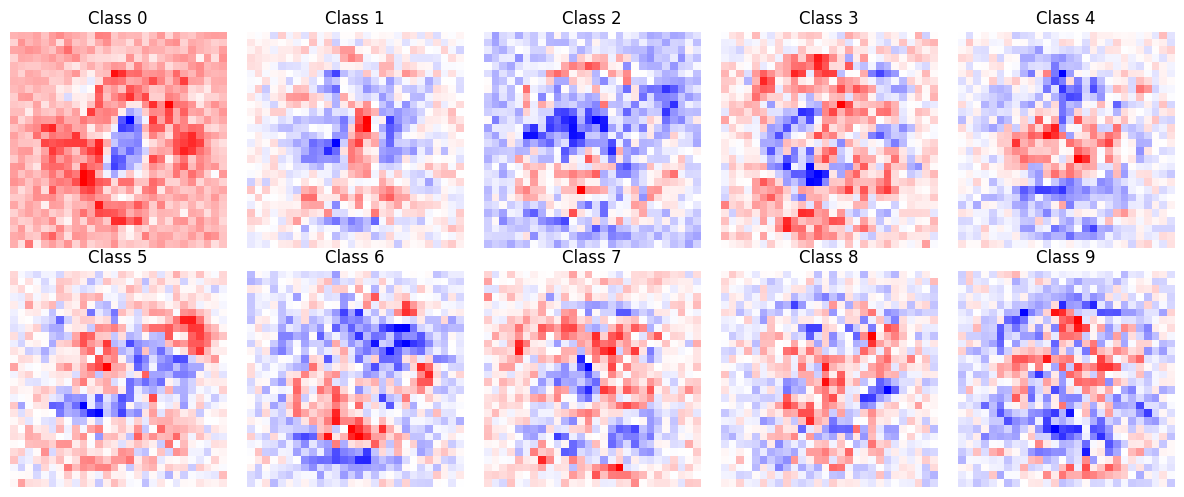

In [20]:
# 1. Start with a blank gray canvas
optimized_image = np.zeros((1, 784))
lr = 0.2

for _ in range(150):
    # Forward pass
    z1 = (optimized_image @ weights1) + biases1
    a1 = np.maximum(0, z1)
    z2 = (a1 @ weights2) + biases2

    # Target gradient: push class 8 score as high as possible
    dz2 = np.zeros((1, 10))
    dz2[0, 8] = 1.0

    # Backpropagate gradient directly to the input image (dL/dX)
    da1 = dz2 @ weights2.T
    dz1 = da1 * (z1 > 0).astype(float)
    dx = dz1 @ weights1.T

    # Gradient ascent step: update the image pixels
    optimized_image += lr * dx

# 2. Plot all 10 digit templates side by side
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    # Project each digit's class vector
    vec = np.zeros((1, 10))
    vec[0, digit] = 1.0
    template = ((vec @ weights2.T) @ weights1.T).reshape(28, 28)

    axes[digit].imshow(template, cmap='bwr')
    axes[digit].set_title(f"Class {digit}")
    axes[digit].axis('off')

plt.tight_layout()
plt.show()